In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline, BitsAndBytesConfig
import random
import os
import csv
import re

In [ ]:
# ------------------------------
# PPO Actor-Critic Network
# ------------------------------

class PPOPolicy(nn.Module):
    def __init__(self, state_dim, num_llms, hidden=128):
        super().__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, num_llms),
            nn.Softmax(dim=-1)
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, state):
        probs = self.actor(state)
        value = self.critic(state)
        return probs, value

In [ ]:
class PPOAgent:
    def __init__(self, state_dim, num_llms, lr=3e-4, gamma=0.99, clip_eps=0.2):
        self.policy = PPOPolicy(state_dim, num_llms)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.gamma = gamma
        self.clip_eps = clip_eps

    def select_action(self, state):
        state = torch.tensor(state, dtype=torch.float32)
        probs, value = self.policy(state)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        return min(action.item(), probs.shape[-1]-1), dist.log_prob(action), value

    def compute_returns(self, rewards, values, dones):
        returns = []
        R = 0
        for r, done in zip(reversed(rewards), reversed(dones)):
            if done:
                R = 0
            R = r + self.gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns, dtype=torch.float32)
        values = torch.cat(values).squeeze().detach()
        advantages = returns - values
        advantages = advantages.detach()
        return returns, advantages

    def update(self, states, actions, old_log_probs, returns, advantages, epochs=5):
        for _ in range(epochs):
            probs, values = self.policy(states)
            dist = torch.distributions.Categorical(probs)
            new_log_probs = dist.log_prob(actions)
            ratio = (new_log_probs - old_log_probs).exp()
            clipped_ratio = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps)
            actor_loss = -torch.min(ratio * advantages, clipped_ratio * advantages).mean()
            critic_loss = (returns - values.squeeze()) ** 2
            critic_loss = critic_loss.mean()
            loss = actor_loss + 0.5 * critic_loss

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()



In [ ]:
class HuggingFaceLLMSystem:
    def __init__(self, model_names, prompts):
        self.model_names = model_names
        self.prompts = prompts
        self.models = [None for _ in model_names]
        self.tokenizers = [None for _ in model_names]

    def extract_rating(self, decoded):
        matches = re.findall(r'\b([1-5])\b', decoded)
        if not matches:
            return 3
        return int(matches[-1])

    def run(self, llm_id, text, language="en"):
        llm_id = min(llm_id, len(self.model_names)-1)

        if self.models[llm_id] is None:
            bnb_cfg = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_use_double_quant=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16
            )
            tokenizer = AutoTokenizer.from_pretrained(self.model_names[llm_id], trust_remote_code=True)
            model = AutoModelForCausalLM.from_pretrained(
                self.model_names[llm_id],
                device_map="auto",
                quantization_config=bnb_cfg,
                trust_remote_code=True
            )
            model.eval()
            self.models[llm_id] = model
            self.tokenizers[llm_id] = tokenizer
        else:
            model = self.models[llm_id]
            tokenizer = self.tokenizers[llm_id]

        prompt_template = self.prompts.get(language, self.prompts["en"])
        prompt = prompt_template.format(text=text)
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(**inputs, max_new_tokens=20)

        decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
        rating = self.extract_rating(decoded)
        print(rating)

        return rating, decoded, prompt, self.model_names[llm_id]

In [ ]:
# ------------------------------
# Routing Pipeline
# ------------------------------

class RoutingPipeline:
    def __init__(self, agent, llm_system, state_dim):
        self.agent = agent
        self.llm_system = llm_system
        self.state_dim = state_dim

    def get_state(self, text, language):
        lang_map = {"en":0, "fr":1, "ja":2, "es":3, "zh":4, "de":5}
        lang_vec = np.zeros(6)
        if language in lang_map:
            lang_vec[lang_map[language]] = 1
        return np.concatenate([np.random.randn(self.state_dim-6), lang_vec])

    def reward_fn(self, pred_rating, true_rating):
        return 1 - abs(pred_rating - true_rating)/4

    def train_step(self, batch, output_csv=None):
        states, actions, old_log_probs, rewards, values, dones = [], [], [], [], [], []

        for _, row in batch.iterrows():
            state = self.get_state(row['review_body'], row['language'])
            action, log_prob, value = self.agent.select_action(state)

            pred_rating, decoded_output, prompt_used, llm_name_used = \
                self.llm_system.run(action, row['review_body'], row['language'])
            print("Actual Star " ,int(row['stars']))
            reward = self.reward_fn(pred_rating, int(row['stars']))

            if output_csv is not None:
                with open(output_csv, "a", newline="", encoding="utf-8") as f:
                    writer = csv.writer(f)
                    writer.writerow([
                        row['review_body'],
                        row['language'],
                        row['stars'],
                        action,
                        pred_rating,
                        decoded_output,
                        prompt_used,
                        llm_name_used
                    ])

            states.append(state)
            actions.append(action)
            old_log_probs.append(log_prob)
            rewards.append(reward)
            values.append(value)
            dones.append(False)

        states = torch.tensor(np.array(states), dtype=torch.float32)
        actions = torch.tensor(actions)
        old_log_probs = torch.stack(old_log_probs).detach()

        returns, advantages = self.agent.compute_returns(rewards, values, dones)
        self.agent.update(states, actions, old_log_probs, returns, advantages)


    def run_single(self, row):
        """
        Run inference for a single review without updating the agent.
        `row` should be a dict with 'review_body', 'language', and 'stars'
        """
        # 1. Prepare state (you may already have a function for this)
        state = self.prepare_state(row)  # returns a tensor of shape [1, state_dim]

        # 2. Get action probabilities from agent (no gradient)
        with torch.no_grad():
            probs, _ = self.agent.policy(state)
            dist = torch.distributions.Categorical(probs)
            action = dist.sample().item()  # chosen LLM index

        # 3. Run the chosen LLM
        prompt = self.llm_system.get_prompt(row['language'], row['review_body'])
        decoded_output = self.llm_system.generate(action, prompt)

        # 4. Convert decoded output to predicted rating (depends on your logic)
        pred_rating = self.llm_system.extract_rating(decoded_output)

        return {
            "action": action,
            "pred_rating": pred_rating,
            "decoded_output": decoded_output,
            "prompt": prompt,
            "llm_name_used": self.llm_system.model_names[action]
        }
    
    

In [ ]:
if __name__ == "__main__":
    state_dim = 20
    num_llms = 2
    batch_size = 4

    model_names = [
        "Qwen/Qwen2.5-3B",
        "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
    ]

    llm_system = HuggingFaceLLMSystem(model_names, PROMPTS)
    agent = PPOAgent(state_dim, num_llms)
    pipeline = RoutingPipeline(agent, llm_system, state_dim)

    output_csv_path = "llm_outputs.csv"
    if not os.path.exists(output_csv_path):
        with open(output_csv_path, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                "review_body","language","true_stars",
                "action","pred_rating","decoded_output",
                "prompt","llm_name_used"
            ])

    data = pd.read_csv("../fyp_multilingual_Text_classification/data/train_subset_final.csv",
                       dtype={'review_body': str, 'language': str, 'stars': int},
                       encoding='utf-8',
                       on_bad_lines='skip')

    for step in range(100):
        batch = data.sample(batch_size)
        pipeline.train_step(batch, output_csv=output_csv_path)
        if step % 10 == 0:
            print(f"Step {step} completed")

    torch.save(agent.policy.state_dict(), "ppo_router_policy_multilang.pth")
    print("Router policy saved successfully.")



=== Language-wise LLM Selection Counts ===
   language  action  count
0        de       0     47
1        de       1     31
2        en       0     46
3        en       1     26
4        es       0     37
5        es       1     35
6        fr       0     50
7        fr       1     31
8        ja       0     49
9        ja       1     20
10       zh       0     48
11       zh       1     25

=== Pivot Table (language × LLM) ===
action     0   1
language        
de        47  31
en        46  26
es        37  35
fr        50  31
ja        49  20
zh        48  25


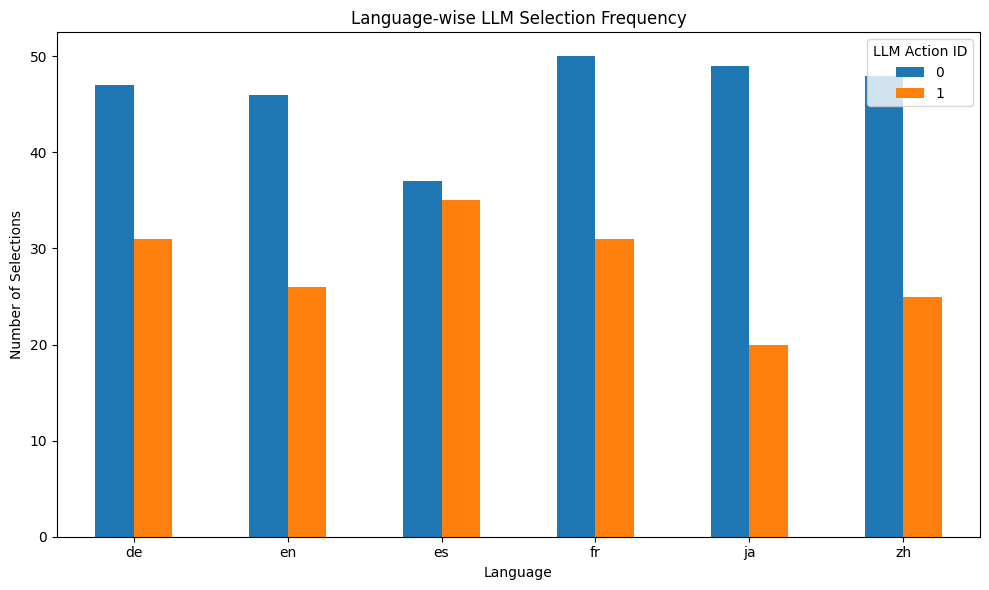

In [ ]:
import pandas as pd

# Load your logged LLM selection data
df = pd.read_csv("llm_outputs.csv")

# Count how many times each LLM was selected per language
counts = df.groupby(["language", "action"]).size().reset_index(name="count")

print("\n=== Language-wise LLM Selection Counts ===")
print(counts)

# Pivot for visualization
pivot = counts.pivot(index="language", columns="action", values="count").fillna(0)

print("\n=== Pivot Table (language × LLM) ===")
print(pivot)

# Plot the bar chart
pivot.plot(kind="bar", figsize=(10, 6))
plt.title("Language-wise LLM Selection Frequency")
plt.xlabel("Language")
plt.ylabel("Number of Selections")
plt.legend(title="LLM Action ID")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()